# Batch BESS sizing across daily solar profiles

Goal: run many daily optimizations (one per solar profile/day) and inspect the distribution of optimal battery sizing outputs for decision-making.

Workflow:
1. Run Cells 1-3 to load data and set parameters.
2. Run Cell 4 to execute batch optimization.
3. Run Cells 5-7 to inspect results and decision metrics.

Notes:
- `battery_power_capacity` and `battery_energy_capacity` are optimized endogenously for each day.
- For tractability, start with a subset of days (for example 10-30), then scale to all days.

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure repository root is on sys.path when running from notebooks/.
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src import Optimizer

print(f"Using repo root: {repo_root}")

Using repo root: c:\Users\Pc\Documents\GitHub\optimal_battery_sizing


c:\Users\Pc\Documents\GitHub\optimal_battery_sizing\.venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# Load solar daily profiles from CSV.
solar_path = repo_root / "data" / "solar_profiles.csv"
solar_df = pd.read_csv(solar_path)

# Expected shape is (hours_per_day, number_of_days).
hours_per_day, n_days = solar_df.shape
print(f"Loaded solar profiles from: {solar_path}")
print(f"hours_per_day={hours_per_day}, number_of_days={n_days}")

# Show the first few day names and first rows.
display(solar_df.iloc[:5, :5])

Loaded solar profiles from: c:\Users\Pc\Documents\GitHub\optimal_battery_sizing\data\solar_profiles.csv
hours_per_day=24, number_of_days=365


,Day_0,Day_1,Day_2,Day_3,Day_4
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0


In [3]:
# USER INPUTS: scenario and optimization assumptions.

# System assumptions
solar_capacity_mw = 300.0
efficiency = 0.90
battery_power_cost = 200_000.0
battery_energy_cost = 300_000.0
max_battery_power = 500.0
max_hours = 8.0
solver_name = "highs"
unmet_penalty = 1e9

# Tractability controls
max_days_to_run = None   # Set to None to run all days
selected_day_indices = None  # Example: [0, 10, 50]. Keep None to use first max_days_to_run days.

# Demand profile (must have same length as each daily solar profile).
# Option A: define a full demand array manually (preferred).
demand_profile = np.array([
    50, 45, 40, 38, 36, 38, 45, 60,
    75, 85, 90, 92, 90, 88, 86, 88,
    92, 95, 90, 80, 70, 65, 58, 52,
], dtype=float)

if len(demand_profile) != hours_per_day:
    raise ValueError(
        f"demand_profile length ({len(demand_profile)}) must match hours_per_day ({hours_per_day})."
    )

In [4]:
# Build the list of days to run.
if selected_day_indices is not None:
    day_indices = [int(i) for i in selected_day_indices]
else:
    if max_days_to_run is None:
        day_indices = list(range(n_days))
    else:
        day_indices = list(range(min(int(max_days_to_run), n_days)))

print(f"Running {len(day_indices)} optimization(s) out of {n_days} available day profiles.")

records = []
batch_start = time.perf_counter()

for run_idx, day_idx in enumerate(day_indices, start=1):
    day_label = solar_df.columns[day_idx]
    solar_profile = solar_df.iloc[:, day_idx].to_numpy(dtype=float)

    t0 = time.perf_counter()
    model = Optimizer(solver_name=solver_name, unmet_penalty=unmet_penalty)
    model.add_solar(capacity=solar_capacity_mw, profile=solar_profile)
    model.add_storage(
        efficiency=efficiency,
        battery_power_cost=battery_power_cost,
        battery_energy_cost=battery_energy_cost,
        max_battery_power=max_battery_power,
        max_hours=max_hours,
    )
    model.add_load(demand=demand_profile)
    model.solve()
    res = model.get_results()
    t1 = time.perf_counter()

    records.append({
        "run_index": run_idx,
        "day_index": day_idx,
        "day_label": day_label,
        "battery_power_capacity_mw": res["battery_power_capacity"],
        "battery_energy_capacity_mwh": res["battery_energy_capacity"],
        "duration_hours": res["battery_energy_capacity"] / max(res["battery_power_capacity"], 1e-9),
        "total_unmet_mwh": res["total_unmet"],
        "objective_value": res["objective_value"],
        "solve_seconds": t1 - t0,
    })

    if run_idx % 10 == 0 or run_idx == len(day_indices):
        elapsed = time.perf_counter() - batch_start
        print(f"Completed {run_idx}/{len(day_indices)} in {elapsed:.1f}s")

results_df = pd.DataFrame(records)
total_elapsed = time.perf_counter() - batch_start
print(f"Batch done: {len(results_df)} runs in {total_elapsed:.2f}s")

Running 365 optimization(s) out of 365 available day profiles.
Completed 10/365 in 56.0s
Completed 20/365 in 131.2s
Completed 30/365 in 213.3s
Completed 40/365 in 287.4s
Completed 50/365 in 363.5s
Completed 60/365 in 440.9s
Completed 70/365 in 510.4s
Completed 80/365 in 584.3s
Completed 90/365 in 655.0s
Completed 100/365 in 738.9s
Completed 110/365 in 819.0s
Completed 120/365 in 892.6s
Completed 130/365 in 978.2s
Completed 140/365 in 1074.0s
Completed 150/365 in 1163.7s
Completed 160/365 in 1253.5s
Completed 170/365 in 1341.1s
Completed 180/365 in 1432.2s
Completed 190/365 in 1524.3s
Completed 200/365 in 1618.7s
Completed 210/365 in 1710.8s
Completed 220/365 in 1804.8s
Completed 230/365 in 1902.8s
Completed 240/365 in 1997.7s
Completed 250/365 in 2093.7s
Completed 260/365 in 2188.1s
Completed 270/365 in 2281.4s
Completed 280/365 in 2371.1s
Completed 290/365 in 2463.3s
Completed 300/365 in 2558.8s
Completed 310/365 in 2650.5s
Completed 320/365 in 2745.0s
Completed 330/365 in 2840.4s
Com

In [5]:
# Inspect summary statistics and top cases.
summary = results_df[[
    "battery_power_capacity_mw",
    "battery_energy_capacity_mwh",
    "duration_hours",
    "total_unmet_mwh",
    "objective_value",
    "solve_seconds",
]].describe(percentiles=[0.1, 0.5, 0.9, 0.95])
display(summary)

print("Largest energy-capacity days:")
display(
    results_df.sort_values("battery_energy_capacity_mwh", ascending=False).head(10)[[
        "day_label", "battery_power_capacity_mw", "battery_energy_capacity_mwh", "duration_hours", "total_unmet_mwh"
    ]]
)

,battery_power_capacity_mw,battery_energy_capacity_mwh,duration_hours,total_unmet_mwh,objective_value,solve_seconds
count,365.000000,365.000000,365.000000,365.000000,3.650000e+02,365.000000
mean,52.799202,262.562441,2.962549,796.732082,7.968214e+11,8.685062
std,47.484602,283.461691,2.631524,563.144236,5.630556e+11,1.199005
min,-0.000000,-0.000000,-0.000000,0.000000,2.118515e+08,4.319932
10%,0.000000,0.000000,0.000000,0.000000,2.350513e+08,7.091629
50%,52.000000,140.689733,2.663861,837.630000,8.377162e+11,8.949936
90%,117.000000,700.992630,7.041082,1568.380000,1.568380e+12,9.953667
95%,127.260000,746.023464,7.924011,1589.200000,1.589200e+12,10.224176
max,156.300000,806.486213,8.000000,1642.000000,1.642000e+12,11.177417


Largest energy-capacity days:


,day_label,battery_power_capacity_mw,battery_energy_capacity_mwh,duration_hours,total_unmet_mwh
89,Day_89,140.911111,806.486213,5.723368,0.00
111,Day_111,119.100000,784.561087,6.587415,0.00
98,Day_98,117.542222,780.871764,6.643330,0.00
100,Day_100,120.527778,778.974397,6.463028,0.00
108,Day_108,140.977778,775.812119,5.503081,0.00
101,Day_101,107.928889,771.701158,7.150089,0.00
86,Day_86,144.900000,769.287286,5.309091,55.39
99,Day_99,102.668519,768.538881,7.485633,0.00
102,Day_102,104.146296,767.273970,7.367271,0.00
226,Day_226,113.160000,763.690055,6.748763,0.00


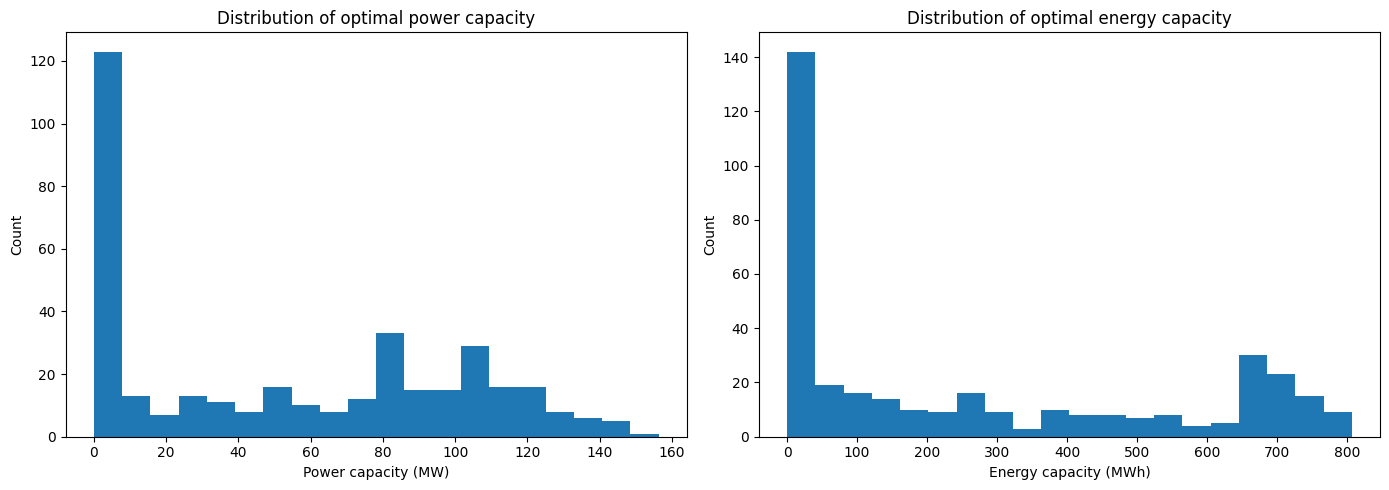

<Figure size 640x480 with 0 Axes>

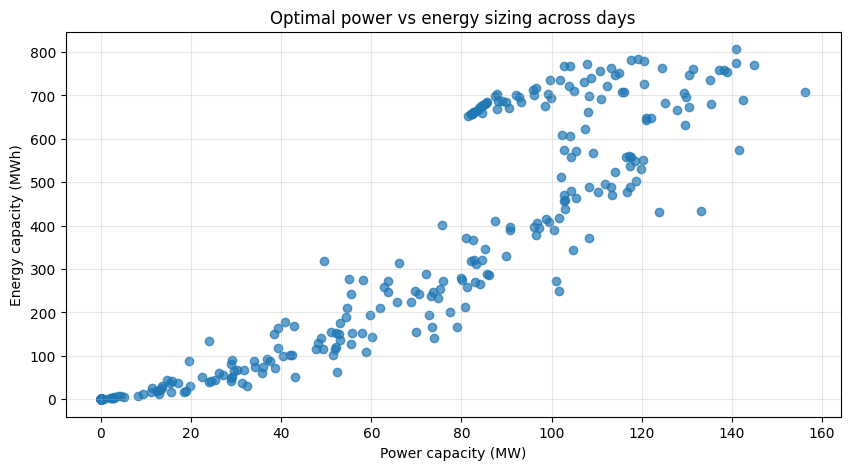

<Figure size 640x480 with 0 Axes>

In [6]:
# Visual inspection for decision-making.

# Histograms of optimal power and energy capacities across days.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(results_df["battery_power_capacity_mw"], bins=20)
axes[0].set_title("Distribution of optimal power capacity")
axes[0].set_xlabel("Power capacity (MW)")
axes[0].set_ylabel("Count")

axes[1].hist(results_df["battery_energy_capacity_mwh"], bins=20)
axes[1].set_title("Distribution of optimal energy capacity")
axes[1].set_xlabel("Energy capacity (MWh)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()
plt.savefig(repo_root / "results" / "capacity_histograms.png")

# Scatter plot of power vs energy capacities 
plt.figure(figsize=(10, 5))
plt.scatter(
    results_df["battery_power_capacity_mw"],
    results_df["battery_energy_capacity_mwh"],
    alpha=0.7,
)
plt.title("Optimal power vs energy sizing across days")
plt.xlabel("Power capacity (MW)")
plt.ylabel("Energy capacity (MWh)")
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig(repo_root / "results" / "power_vs_energy_scatter.png")

The chart above summarizes the results of the analysis against different solar daily profiles, and in particular it shows the optmimal battery sizing for each day individually considered (in this case, all the 365 days of an year). 

After having evaluate the optimal battery sizing algorithm against different solar profiles (over a year), 
- how to choose the optimal battery size? 
- how suitable this model is for finding the optimal battery size? 

This model is a good first-order optimization model for sizing a battery under a known load and solar profile. 

It is suitable for screening, sensitivity analysis, and understanding the trade-off between battery power and energy capacity. However, choosing the actual project battery requires one fixed design to be evaluated across the full year, against reliability and economic criteria, not just daily optimal solutions. Therefore, the model is suitable for generating candidate sizes and understanding sizing drivers, but not sufficient on its own for final battery selection.

This means that this model is good for answering: “For this assumed day/profile, what is the least-cost battery that can make the system feasible?” but it is not enough to answer: “What battery should I build for the site under real uncertainty over a year or multiple years?”

A first screening idea for battery sizing could be using a statistical approach based on quantiles of the found distribution. The MAX approach takes the worst day of the whole year and use those paramaters as optimal. In this way you size the battery on the worst simulated day and it is operationally safe but not efficient. Alternatively you can decide on a treshold on which to select the decision sizing variable (power, energy) and you can based this decision on the quantiles of the found distribution. This an approximative approach. Take a look at the next notebook, in the next cell follows an example of the approach.  

In [7]:
# Decision-support sizing rules from the simulated day set.
power_p90 = results_df["battery_power_capacity_mw"].quantile(0.90)
energy_p90 = results_df["battery_energy_capacity_mwh"].quantile(0.90)
power_max = results_df["battery_power_capacity_mw"].max()
energy_max = results_df["battery_energy_capacity_mwh"].max()

print("Suggested capacity options based on batch results:")
print(f"- P90 sizing:  power={power_p90:.2f} MW, energy={energy_p90:.2f} MWh")
print(f"- Max sizing:  power={power_max:.2f} MW, energy={energy_max:.2f} MWh")

output_path = repo_root / "results" / "batch_daily_sizing_results.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_path, index=False)
print(f"Saved detailed results to: {output_path}")

Suggested capacity options based on batch results:
- P90 sizing:  power=117.00 MW, energy=700.99 MWh
- Max sizing:  power=156.30 MW, energy=806.49 MWh
Saved detailed results to: c:\Users\Pc\Documents\GitHub\optimal_battery_sizing\results\batch_daily_sizing_results.csv
